# <img style="float: left; padding-right: 20px; height: 70px" src="https://i.imgur.com/cMzxwTN.jpg"> Fundamentos de Machine Learning
## Actividad I, Varianza en Arboles de decision

<h4>

**Universidad Privada Boliviana**<br/>
**Diplomado en Machine Learning y Ciencia de Datos**<br/>

<h4>

<div style="line-height: 1.5">

### ■ La Fragilidad de los Árboles: Alta Varianza

En esta unidad utilizaremos el dataset forense **`glass.csv`** para clasificar tipos de vidrio basándonos en su composición química. 

**El Problema de la Alta Varianza:**
Los Árboles de Decisión tienden a memorizar detalles muy específicos de los datos. Si alteramos ligeramente el conjunto de entrenamiento (ej. quitando un par de filas aleatorias), el árbol generará reglas totalmente distintas. Esto hace que su precisión (*Accuracy*) sea inestable y rebote como una "montaña rusa".

#### Celda 1: Experimento de Entrenamiento Iterativo
Para demostrar esta inestabilidad, dejaremos un Test Set fijo y entrenaremos 15 árboles distintos. A cada árbol le pasaremos un subconjunto de entrenamiento ligeramente modificado (cambiando la semilla `random_state`).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Cargar datos y separar X e y
df = pd.read_csv('glass.csv')
X = df.drop('Type', axis=1)
y = df['Type']

# Aislar un Test Set INAMOVIBLE para evaluar a todos por igual
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
df.tail()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
209,1.51623,14.14,0.0,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.0,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.0,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.0,1.94,73.61,0.00,8.48,1.57,0.0,7
213,1.51711,14.23,0.0,2.08,73.36,0.00,8.62,1.67,0.0,7


In [6]:
n_arboles = 15
exactitudes = []

for i in range(n_arboles):
    # Muestra alterada: Tomamos un 80% de los datos de entrenamiento cada vez
    X_sub, _, y_sub, _ = train_test_split(X_train_full, y_train_full, train_size=0.8)
    
    # Instanciar y ajustar
    arbol = DecisionTreeClassifier()
    arbol.fit(X_sub, y_sub)
    
    # Guardar la Exactitud (Accuracy) de este árbol
    acc = arbol.score(X_test, y_test)
    exactitudes.append(acc)

<div style="line-height: 1.5">

#### Celda 2: Visualización de la Fluctuación (La "Montaña Rusa")
Un algoritmo robusto mostraría una línea plana. Graficaremos las exactitudes obtenidas para observar la verdadera inestabilidad de un Árbol de Decisión individual.


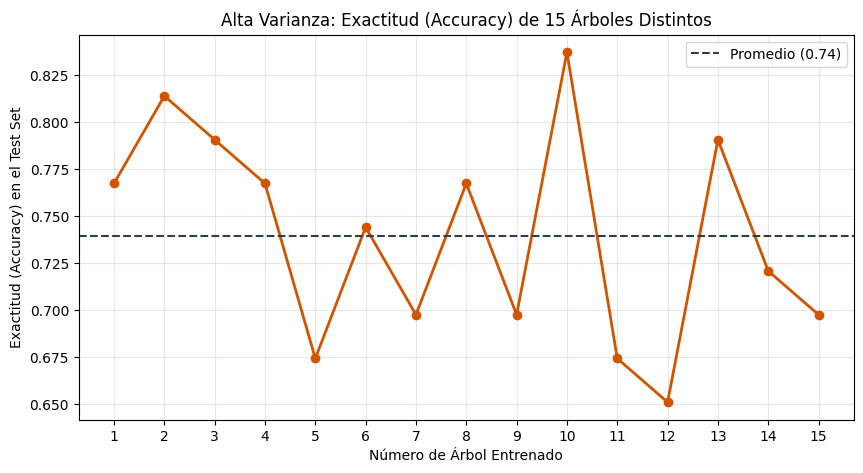

In [7]:
# Graficar los resultados
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_arboles + 1), exactitudes, marker='o', linestyle='-', color='#d35400', linewidth=2)

# Agregar una línea para el promedio de Exactitud
promedio = np.mean(exactitudes)
plt.axhline(promedio, color='#2c3e50', linestyle='--', label=f'Promedio ({promedio:.2f})')

plt.title("Alta Varianza: Exactitud (Accuracy) de 15 Árboles Distintos")
plt.xlabel("Número de Árbol Entrenado")
plt.ylabel("Exactitud (Accuracy) en el Test Set")
plt.xticks(range(1, n_arboles + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


<div style="line-height: 1.5">

### Síntesis del Problema y Conclusión

**Análisis Visual:** Al observar el gráfico, notará que la precisión salta drásticamente (ej. del 78% cayendo súbitamente al 62%) dependiendo de la muestra que vio el árbol. Esta fluctuación confirma que los árboles individuales sufren de **Alta Varianza**.

**El Puente hacia la Solución: Bagging**
Un solo árbol es demasiado sensible e inestable para producción. Pero observe la línea promedio (punteada oscura) en su gráfico. Si en lugar de usar un solo modelo, entrenamos múltiples árboles inestables y hacemos que **voten** para dar una respuesta consensuada, logramos un modelo sumamente robusto. A esta técnica de ensamblaje se le conoce como **Bagging (Bootstrap Aggregating)**, el cual será nuestro siguiente tema.
